<a href="https://colab.research.google.com/github/sukhman22a/ml/blob/main/chest_x_ray_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
print('hello')
!pip install ultralytics

hello
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Create a new YOLOv11 model (for classification)
model = YOLO('yolo11n-cls.pt')  # 'n' = nano, smallest model (fastest for Kaggle)

# Train the model
model.train(
    data='/kaggle/input/chest-xray-pneumonia/chest_xray',
    val=True,
    epochs=20,
    imgsz=224,   # standard for classification
    batch=4
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/chest-xray-pneumonia/chest_xray, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, 

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bb92b4cf5f0>
curves: []
curves_results: []
fitness: 1.0
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 1.0, 'metrics/accuracy_top5': 1.0, 'fitness': 1.0}
save_dir: PosixPath('/content/runs/classify/train')
speed: {'preprocess': 0.10641675001465956, 'inference': 4.907266624996964, 'loss': 0.0011012500351625931, 'postprocess': 0.0014857500048037764}
task: 'classify'
top1: 1.0
top5: 1.0

In [ ]:
from ultralytics import YOLO

# Load your trained weights (replace path if needed)
model = YOLO('/content/runs/classify/train/weights/best.pt')



image 1/1 /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg: 224x224 PNEUMONIA 1.00, NORMAL 0.00, 5.1ms
Speed: 8.5ms preprocess, 5.1ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


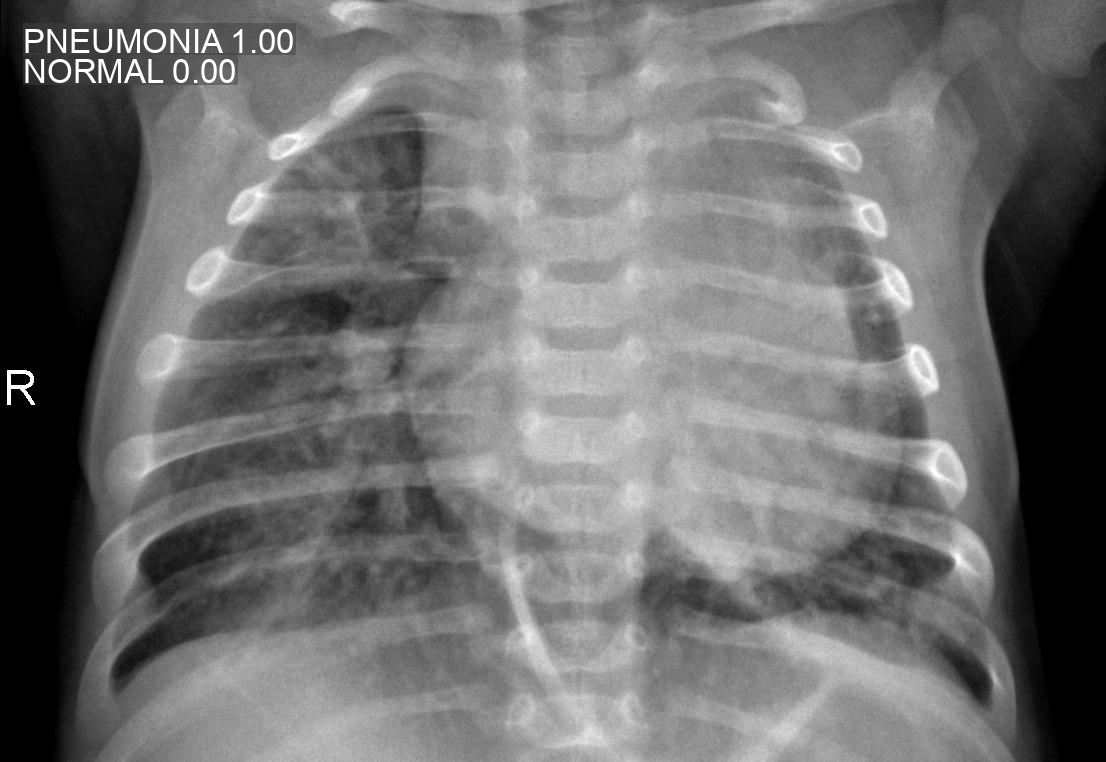

ultralytics.engine.results.Probs object with attributes:

data: tensor([0.0012, 0.9988], device='cuda:0')
orig_shape: None
shape: torch.Size([2])
top1: 1
top1conf: tensor(0.9988, device='cuda:0')
top5: [1, 0]
top5conf: tensor([0.9988, 0.0012], device='cuda:0')
Predicted class: PNEUMONIA  |  Confidence: 1.00


In [ ]:
# Path to a single image
image_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg'

# Predict
results = model.predict(image_path, imgsz=224)

# Show the result (in Kaggle this will display the image inline)
results[0].show()

# Print the predicted class and confidence
print(results[0].probs)  # shows class probabilities
print(f"Predicted class: {results[0].names[results[0].probs.top1]}  |  Confidence: {results[0].probs.top1conf:.2f}")
